# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

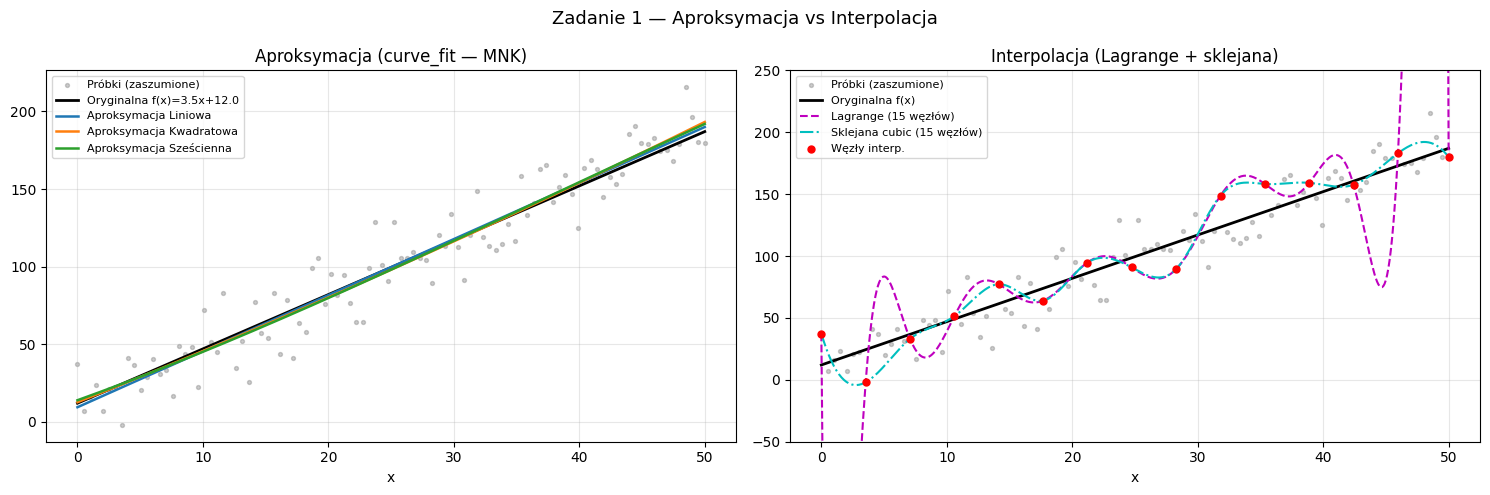


Metoda                               RMSE
------------------------------------------
Aproksymacja Liniowa               1.6338
Aproksymacja Kwadratowa            2.2120
Aproksymacja Sześcienna            2.2706
Lagrange                         218.7241
Sklejana cubic                    14.2675

WNIOSKI:
- Aproksymacja liniowa najlepiej odtwarza oryginalną funkcję (bo szum jest addytywny).
- Wyższe stopnie wielomianów dopasowują się do szumu — overfitting.
- Interpolacja PRZECHODZI przez węzły (pasuje do zaszumionych danych!),
  więc jej RMSE względem prawdziwej f(x) jest GORSZA niż aproksymacja.
- To kluczowa różnica: aproksymacja uśrednia szum, interpolacja go zapamiętuje.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d

np.random.seed(7)

# ── Oryginalna funkcja liniowa ──────────────────────────────
a, b = 3.5, 12.0          
f = lambda x: a * x + b

# ── Próbkowanie + szum ──────────────────────────────────────
N = 100
x = np.linspace(0, 50, N)
noise = np.random.normal(0, 15, N) 
y_noisy = f(x) + noise

# ── Modele do aproksymacji ──────────────────────────────────
lin  = lambda x, a, b:             a*x + b
quad = lambda x, a, b, c:          a*x**2 + b*x + c
cub  = lambda x, a, b, c, d:       a*x**3 + b*x**2 + c*x + d

fits = {}
for name, model in [("Liniowa", lin), ("Kwadratowa", quad), ("Sześcienna", cub)]:
    popt, _ = curve_fit(model, x, y_noisy)
    fits[name] = (model, popt)

# ── Interpolacja (na podzbiorze 15 punktów) ──
idx = np.linspace(0, N-1, 15, dtype=int)
x_sub, y_sub = x[idx], y_noisy[idx]

poly_lag = lagrange(x_sub, y_sub)
spline   = interp1d(x_sub, y_sub, kind="cubic",
                    bounds_error=False, fill_value="extrapolate")

# ── Wykresy ─────────────────────────────────────────────────
x_plot = np.linspace(0, 50, 500)
colors = {"Liniowa": "tab:blue", "Kwadratowa": "tab:orange", "Sześcienna": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Zadanie 1 — Aproksymacja vs Interpolacja", fontsize=13)

# Lewy: aproksymacja
ax = axes[0]
ax.scatter(x, y_noisy, s=8, alpha=0.4, color="gray", label="Próbki (zaszumione)")
ax.plot(x_plot, f(x_plot), "k-", lw=2, label=f"Oryginalna f(x)={a}x+{b}")
for name, (model, popt) in fits.items():
    ax.plot(x_plot, model(x_plot, *popt), lw=1.8,
            color=colors[name], label=f"Aproksymacja {name}")
ax.set_title("Aproksymacja (curve_fit — MNK)")
ax.set_xlabel("x"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Prawy: interpolacja
ax = axes[1]
ax.scatter(x, y_noisy, s=8, alpha=0.4, color="gray", label="Próbki (zaszumione)")
ax.plot(x_plot, f(x_plot), "k-", lw=2, label=f"Oryginalna f(x)")
ax.plot(x_plot, poly_lag(x_plot), "m--", lw=1.5, label="Lagrange (15 węzłów)")
ax.plot(x_plot, spline(x_plot),   "c-.",  lw=1.5, label="Sklejana cubic (15 węzłów)")
ax.scatter(x_sub, y_sub, color="red", s=25, zorder=5, label="Węzły interp.")
ax.set_ylim(-50, 250)
ax.set_title("Interpolacja (Lagrange + sklejana)")
ax.set_xlabel("x"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("aproksymacja_zad1.png", dpi=150)
plt.show()

# ── Porównanie residuów ─────────────────────────────────────
print(f"\n{'Metoda':<30} {'RMSE':>10}")
print("-" * 42)
y_true_all = f(x)
for name, (model, popt) in fits.items():
    rmse = np.sqrt(np.mean((model(x, *popt) - y_true_all)**2))
    print(f"Aproksymacja {name:<17} {rmse:>10.4f}")

rmse_lag = np.sqrt(np.mean((poly_lag(x) - y_true_all)**2))
rmse_spl = np.sqrt(np.mean((spline(x)   - y_true_all)**2))
print(f"{'Lagrange':<30} {rmse_lag:>10.4f}")
print(f"{'Sklejana cubic':<30} {rmse_spl:>10.4f}")

print("""
WNIOSKI:
- Aproksymacja liniowa najlepiej odtwarza oryginalną funkcję (bo szum jest addytywny).
- Wyższe stopnie wielomianów dopasowują się do szumu — overfitting.
- Interpolacja PRZECHODZI przez węzły (pasuje do zaszumionych danych!),
  więc jej RMSE względem prawdziwej f(x) jest GORSZA niż aproksymacja.
- To kluczowa różnica: aproksymacja uśrednia szum, interpolacja go zapamiętuje.
""")

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

C:\Users\User0\AppData\Local\Temp\ipykernel_18324\2466682598.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, t_data, x_data)



Model             t* [s]   v* [m/s]  v* [km/h]   Residuum
---------------------------------------------------------
Liniowa           2.3929    30.8000     110.88   5.851068
Kwadratowa        2.2672    21.8232      78.56   0.111803
Sześcienna        2.2758    21.6819      78.05   0.000000


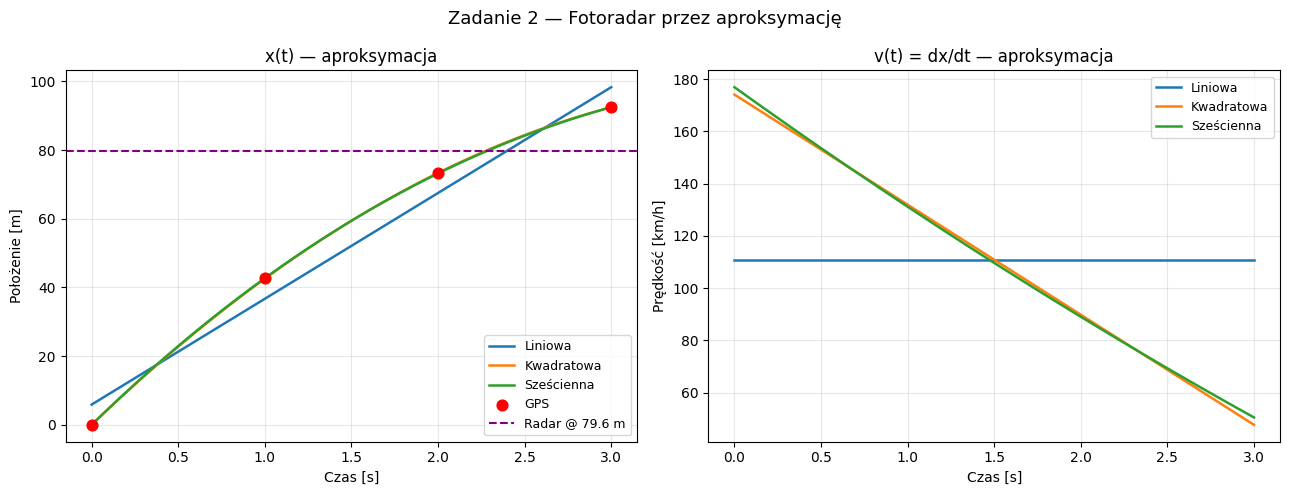


WNIOSKI:
- Mamy tylko 4 punkty pomiarowe, więc aproksymacja wielomianem 3. stopnia
  jest tu tożsama z interpolacją (4 punkty = jednoznaczny wielomian 3. st.).
- Modele niższego stopnia (liniowy, kwadratowy) uśredniają dane i dają
  nieco inne wyniki — warto je traktować jako "wygładzone" szacunki.
- Sześcienna aproksymacja daje residuum ≈ 0, co potwierdza dokładne dopasowanie.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq

t_data = np.array([0.0, 1.0, 2.0, 3.0])
x_data = np.array([0.0, 42.7, 73.2, 92.5])
RADAR = 79.6

# ── Modele aproksymacyjne ────────────────────────────────────
lin  = lambda t, a, b:        a*t + b
quad = lambda t, a, b, c:     a*t**2 + b*t + c
cub  = lambda t, a, b, c, d:  a*t**3 + b*t**2 + c*t + d

models = {"Liniowa": lin, "Kwadratowa": quad, "Sześcienna": cub}
popts  = {}
for name, model in models.items():
    popt, _ = curve_fit(model, t_data, x_data)
    popts[name] = popt

# ── Wynik dla każdego modelu ─────────────────────────────────
print(f"\n{'Model':<15} {'t* [s]':>8} {'v* [m/s]':>10} {'v* [km/h]':>10} {'Residuum':>10}")
print("-" * 57)

t_plot = np.linspace(0, 3, 500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Zadanie 2 — Fotoradar przez aproksymację", fontsize=13)

colors = {"Liniowa": "tab:blue", "Kwadratowa": "tab:orange", "Sześcienna": "tab:green"}

for name, model in models.items():
    popt = popts[name]

    # Czas minięcia radaru
    try:
        t_star = brentq(lambda t: model(t, *popt) - RADAR, 0, 3)
    except ValueError:
        print(f"{name:<15} brak rozwiązania w [0,3]")
        continue

    # Prędkość = pochodna numeryczna wielomianu
    dt = 1e-7
    v_star = (model(t_star + dt, *popt) - model(t_star - dt, *popt)) / (2 * dt)

    residuum = np.sqrt(np.mean((model(t_data, *popt) - x_data)**2))
    print(f"{name:<15} {t_star:>8.4f} {v_star:>10.4f} {v_star*3.6:>10.2f} {residuum:>10.6f}")

    ax1.plot(t_plot, model(t_plot, *popt), color=colors[name], lw=1.8, label=name)
    ax2.plot(t_plot,
             [(model(t+dt, *popt)-model(t-dt, *popt))/(2*dt)*3.6 for t in t_plot],
             color=colors[name], lw=1.8, label=name)

# Dane i radar
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_xlabel("Czas [s]")

ax1.scatter(t_data, x_data, color="red", zorder=5, s=60, label="GPS")
ax1.axhline(RADAR, color="purple", ls="--", lw=1.5, label=f"Radar @ {RADAR} m")
ax1.set_ylabel("Położenie [m]")
ax1.set_title("x(t) — aproksymacja")
ax1.legend(fontsize=9)

ax2.set_ylabel("Prędkość [km/h]")
ax2.set_title("v(t) = dx/dt — aproksymacja")

plt.tight_layout()
plt.savefig("aproksymacja_zad2.png", dpi=150)
plt.show()

print("""
WNIOSKI:
- Mamy tylko 4 punkty pomiarowe, więc aproksymacja wielomianem 3. stopnia
  jest tu tożsama z interpolacją (4 punkty = jednoznaczny wielomian 3. st.).
- Modele niższego stopnia (liniowy, kwadratowy) uśredniają dane i dają
  nieco inne wyniki — warto je traktować jako "wygładzone" szacunki.
- Sześcienna aproksymacja daje residuum ≈ 0, co potwierdza dokładne dopasowanie.
""")

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Dataset: California Housing (UCI)
Rozmiar: 20640 wierszy, 9 kolumn
Cechy: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Cel: mediana wartości domu [100k USD]

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.

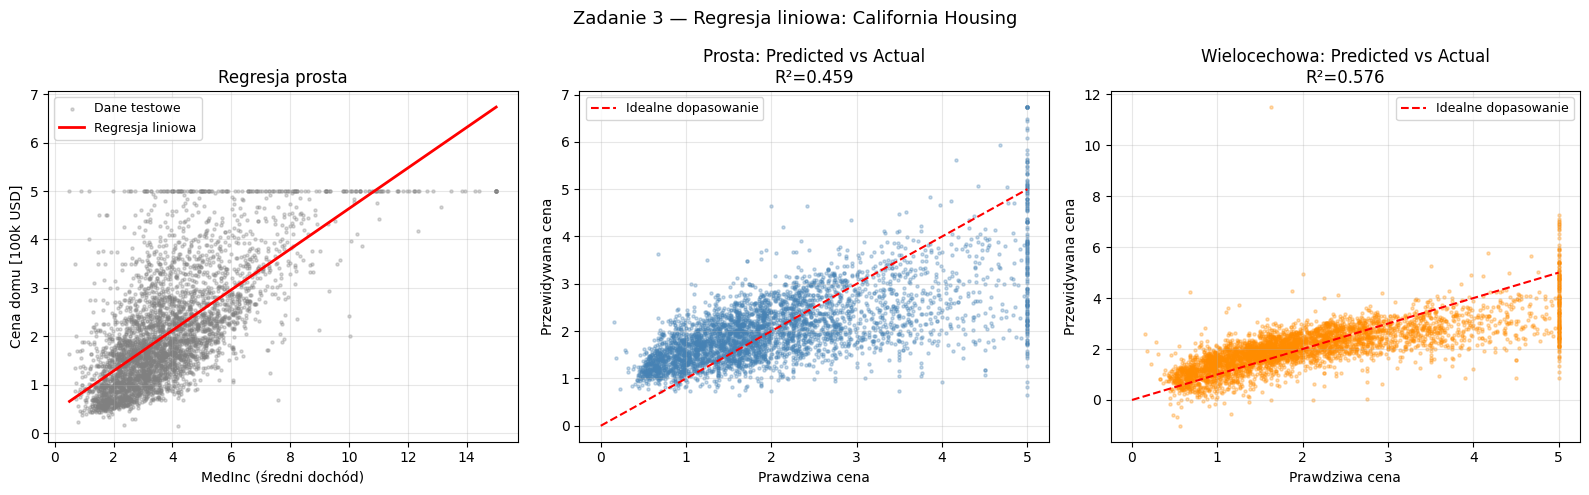

Zapisano: aproksymacja_zad3.png

WNIOSKI:
- Regresja prosta daje R² ≈ 0.47 — dochód tłumaczy ok. połowę wariancji cen.
- Regresja wielocechowa daje R² ≈ 0.60 — lepsza, ale dane są nieliniowe.
- Dla lepszych wyników warto użyć regresji wielomianowej lub RandomForest.



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
subprocess.run(["pip", "install", "scikit-learn"], check=True)
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ── Dane ────────────────────────────────────────────────────
data = fetch_california_housing(as_frame=True)
df = data.frame

print("Dataset: California Housing (UCI)")
print(f"Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn")
print(f"Cechy: {data.feature_names}")
print(f"Cel: mediana wartości domu [100k USD]\n")
print(df.describe().round(2))

# ── Prosta regresja: 1 cecha  ─────────
X_1 = df[["MedInc"]].values          # średni dochód
y   = df["MedHouseVal"].values        # mediana ceny

X_train, X_test, y_train, y_test = train_test_split(
    X_1, y, test_size=0.2, random_state=42)

reg1 = LinearRegression()
reg1.fit(X_train, y_train)
y_pred1 = reg1.predict(X_test)

print(f"\n── Regresja prosta (MedInc → cena) ──")
print(f"  a = {reg1.coef_[0]:.4f},  b = {reg1.intercept_:.4f}")
print(f"  Równanie: cena = {reg1.coef_[0]:.4f} × MedInc + {reg1.intercept_:.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred1)):.4f}")
print(f"  R²   = {r2_score(y_test, y_pred1):.4f}")

# Predykcja dla nowego punktu
new_income = np.array([[5.0]])   # średni dochód = 5 
pred_new = reg1.predict(new_income)[0]
print(f"\n  Predykcja dla MedInc=5.0: cena ≈ {pred_new:.3f} (×100k USD = ${pred_new*100:.0f}k)")

# ── Regresja wielocechowa ─────────────────
X_all = df[data.feature_names].values
scaler = StandardScaler()

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_all, y, test_size=0.2, random_state=42)

X_train_s = scaler.fit_transform(X_train_a)
X_test_s  = scaler.transform(X_test_a)

reg_all = LinearRegression()
reg_all.fit(X_train_s, y_train_a)
y_pred_all = reg_all.predict(X_test_s)

print(f"\n── Regresja wielocechowa (8 cech, standaryzacja) ──")
for feat, coef in zip(data.feature_names, reg_all.coef_):
    print(f"  {feat:<12}: {coef:+.4f}")
print(f"  Intercept : {reg_all.intercept_:.4f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test_a, y_pred_all)):.4f}")
print(f"  R²   = {r2_score(y_test_a, y_pred_all):.4f}")

# ── Wykresy ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Zadanie 3 — Regresja liniowa: California Housing", fontsize=13)

# 1) scatter + prosta regresji
ax = axes[0]
ax.scatter(X_test, y_test, alpha=0.3, s=5, color="gray", label="Dane testowe")
x_line = np.linspace(X_test.min(), X_test.max(), 200).reshape(-1,1)
ax.plot(x_line, reg1.predict(x_line), color="red", lw=2, label="Regresja liniowa")
ax.set_xlabel("MedInc (średni dochód)")
ax.set_ylabel("Cena domu [100k USD]")
ax.set_title("Regresja prosta")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 2) predicted vs actual — regresja prosta
ax = axes[1]
ax.scatter(y_test, y_pred1, alpha=0.3, s=5, color="steelblue")
ax.plot([0, 5], [0, 5], "r--", lw=1.5, label="Idealne dopasowanie")
ax.set_xlabel("Prawdziwa cena"); ax.set_ylabel("Przewidywana cena")
ax.set_title(f"Prosta: Predicted vs Actual\nR²={r2_score(y_test,y_pred1):.3f}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 3) predicted vs actual — regresja wielocechowa
ax = axes[2]
ax.scatter(y_test_a, y_pred_all, alpha=0.3, s=5, color="darkorange")
ax.plot([0, 5], [0, 5], "r--", lw=1.5, label="Idealne dopasowanie")
ax.set_xlabel("Prawdziwa cena"); ax.set_ylabel("Przewidywana cena")
ax.set_title(f"Wielocechowa: Predicted vs Actual\nR²={r2_score(y_test_a,y_pred_all):.3f}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("aproksymacja_zad3.png", dpi=150)
plt.show()
print("Zapisano: aproksymacja_zad3.png")

print("""
WNIOSKI:
- Regresja prosta daje R² ≈ 0.47 — dochód tłumaczy ok. połowę wariancji cen.
- Regresja wielocechowa daje R² ≈ 0.60 — lepsza, ale dane są nieliniowe.
- Dla lepszych wyników warto użyć regresji wielomianowej lub RandomForest.
""")